## Exploratory Data Analysis (EDA) for Heart Disease Dataset - Part 1
#### About Dataset

***Source***: Kaggle - [Heart Disease Prediction Dataset]
(https://www.kaggle.com/datasets/nalisha/heart-disease-prediction-dataset/data)
#### Data Description :
- Includes 270 Patient Medical Records with 14 Features
- Features include Age, Sex, Chest Pain, BP, Cholesterol, FBS over 120, EKG Results, Max HR, Exercise Angina, ST Depression, 
  Slope of ST, Number of Vessels Fluro, Thalium and the key Target variable indicating presence of Heart Disease.

- Goal is to predict presence of Heart Disease based on these features using classification models.

-- License CCO (public domain)
i
- This notebook performs an initial exploratory analysis of the heart disease dataset, focusing on understanding data quality, 
- structure, and key patterns. The goal is to inspect distributions, identify missing or anomalous values, and generate early 
- insights that will guide subsequent feature engineering and modeling steps

### Categorical Data Features Explained

#### Sex
- 1 = male  
- 0 = female  

#### Chest Pain Type
- 4 = Asymptomatic  
- 3 = Non-anginal chest pain  
- 2 = Atypical angina  
- 1 = Typical angina  

#### FBS over 120 (Fasting Blood Sugar > 120)
- 1 = Yes  
- 0 = No  

#### EKG Results
- 2 = Probable left ventricular hypertrophy  
- 1 = ST-T wave abnormality  
- 0 = Normal  

#### Exercise Angina
- 1 = Yes  
- 0 = No  

#### Slope of ST
- 3 = Downsloping: strong indicator of coronary heart disease  
- 2 = Flat/horizontal: moderate indicator of coronary heart disease (inadequate flow to the heart muscle)  
- 1 = Upsloping: lowest risk of coronary heart disease (normal response to stress)  

#### Number of Vessels Fluoro
- 0, 1, 2, or 3 vessels have narrowed  

#### Thallium
- 3 = Normal blood flow  
- 6 = Fixed defect: reduced blood flow at rest and stress, usually indicating previous heart attack  
- 7 = Reversible defect: normal blood flow at rest and reduced flow during stress (ischemia, significant narrowing, high risk)  


In [47]:
## Import necessary libraries/Packages
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import joblib
import xgboost as xgb
import pandas as pd

pd.set_option('display.max_rows', None)       # show all rows
pd.set_option('display.max_columns', None)    # show all columns
pd.set_option('display.width', 0)             # let pandas use full width


## Load the raw heart disease dataset
df_heart_raw = pd.read_csv('../../data/raw/Heart_Disease_Prediction.csv')
df_heart_raw.head(10)

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
5,65,1,4,120,177,0,0,140,0,0.4,1,0,7,Absence
6,56,1,3,130,256,1,2,142,1,0.6,2,1,6,Presence
7,59,1,4,110,239,0,2,142,1,1.2,2,1,7,Presence
8,60,1,4,140,293,0,2,170,0,1.2,2,2,7,Presence
9,63,0,4,150,407,0,2,154,0,4.0,2,3,7,Presence


In [48]:
## convert column names to lowercase without overwriting the dataframe
df_heart_raw.columns = df_heart_raw.columns.str.lower()
df_heart_raw.head(10)

,age,sex,chest pain type,bp,cholesterol,fbs over 120,ekg results,max hr,exercise angina,st depression,slope of st,number of vessels fluro,thallium,heart disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence
5,65,1,4,120,177,0,0,140,0,0.4,1,0,7,Absence
6,56,1,3,130,256,1,2,142,1,0.6,2,1,6,Presence
7,59,1,4,110,239,0,2,142,1,1.2,2,1,7,Presence
8,60,1,4,140,293,0,2,170,0,1.2,2,2,7,Presence
9,63,0,4,150,407,0,2,154,0,4.0,2,3,7,Presence


In [49]:
## Gather Basic Info about the dataset
df_heart_raw.info()

## No Null missing values in the dataset
df_heart_raw.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      270 non-null    int64  
 1   sex                      270 non-null    int64  
 2   chest pain type          270 non-null    int64  
 3   bp                       270 non-null    int64  
 4   cholesterol              270 non-null    int64  
 5   fbs over 120             270 non-null    int64  
 6   ekg results              270 non-null    int64  
 7   max hr                   270 non-null    int64  
 8   exercise angina          270 non-null    int64  
 9   st depression            270 non-null    float64
 10  slope of st              270 non-null    int64  
 11  number of vessels fluro  270 non-null    int64  
 12  thallium                 270 non-null    int64  
 13  heart disease            270 non-null    object 
dtypes: float64(1), int64(12), 

age                        0
sex                        0
chest pain type            0
bp                         0
cholesterol                0
fbs over 120               0
ekg results                0
max hr                     0
exercise angina            0
st depression              0
slope of st                0
number of vessels fluro    0
thallium                   0
heart disease              0
dtype: int64

In [50]:
df_heart_raw.shape


(270, 14)

## No Null Values 

In [51]:
df_heart_raw.describe()

,age,sex,chest pain type,bp,cholesterol,fbs over 120,ekg results,max hr,exercise angina,st depression,slope of st,number of vessels fluro,thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


- Avg Age = 54.43
- Avg Blood Pressure = 131
- Avg Cholesterol Level = 249.66
- Avg Max Heart Rate = 149.68

In [52]:
## No duplicate rows in the dataset
dupes = df_heart_raw[df_heart_raw.duplicated()]

dupes.head()

,age,sex,chest pain type,bp,cholesterol,fbs over 120,ekg results,max hr,exercise angina,st depression,slope of st,number of vessels fluro,thallium,heart disease


- No duplicate values are present in this dataset

In [53]:
categorical_columns = ['sex', 'chest pain type', 'fbs over 120', 'ekg results', 'exercise angina', 'slope of st', 'number of vessels fluro', 'thallium']

df_heart_raw[categorical_columns] = df_heart_raw[categorical_columns].astype('category')
df_heart_raw.columns = df_heart_raw.columns.str.replace(' ', '_').str.lower()


df_heart_cleaned = df_heart_raw.copy()
df_heart_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   age                      270 non-null    int64   
 1   sex                      270 non-null    category
 2   chest_pain_type          270 non-null    category
 3   bp                       270 non-null    int64   
 4   cholesterol              270 non-null    int64   
 5   fbs_over_120             270 non-null    category
 6   ekg_results              270 non-null    category
 7   max_hr                   270 non-null    int64   
 8   exercise_angina          270 non-null    category
 9   st_depression            270 non-null    float64 
 10  slope_of_st              270 non-null    category
 11  number_of_vessels_fluro  270 non-null    category
 12  thallium                 270 non-null    category
 13  heart_disease            270 non-null    object  
dtypes: categor

In [74]:
## Save 1st version of cleaned data
df_heart_cleaned.to_csv('../../data/interim/df_heart_cleaned_v1.csv', index=False)

In [55]:
df_heart_cleaned['heart_disease'].value_counts(normalize=True)   * 100

heart_disease
Absence     55.555556
Presence    44.444444
Name: proportion, dtype: float64

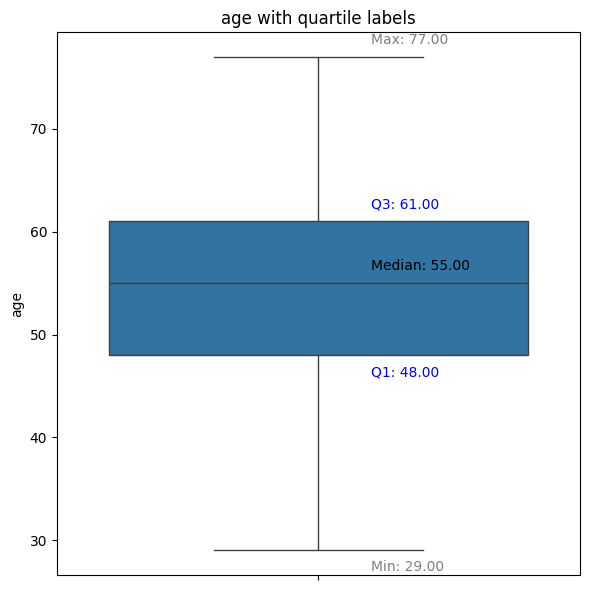

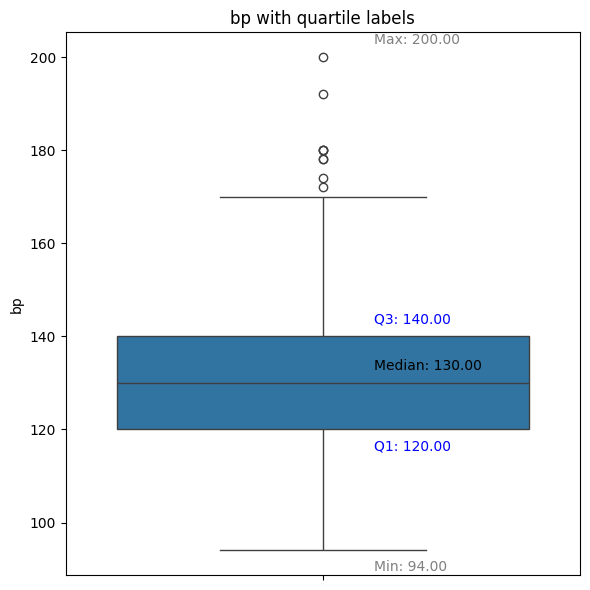

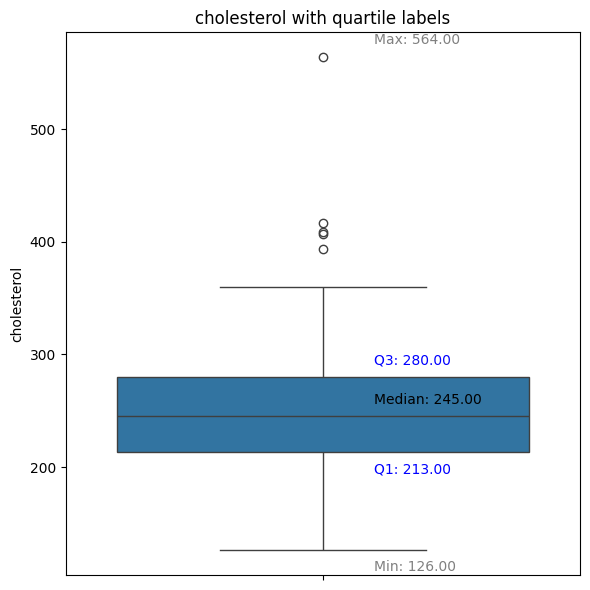

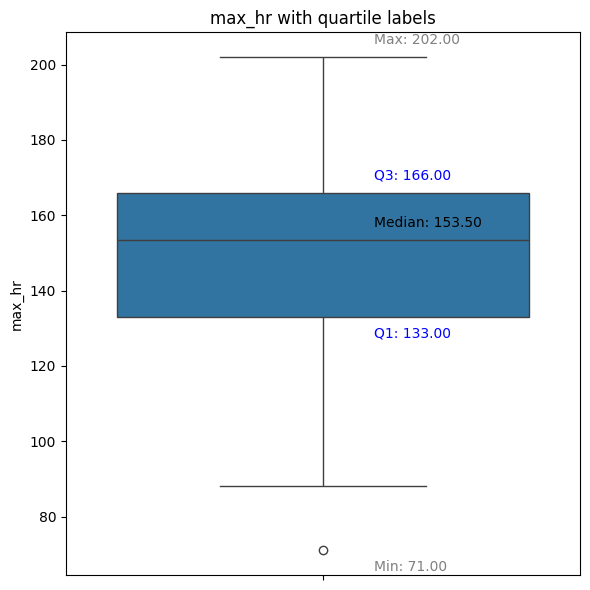

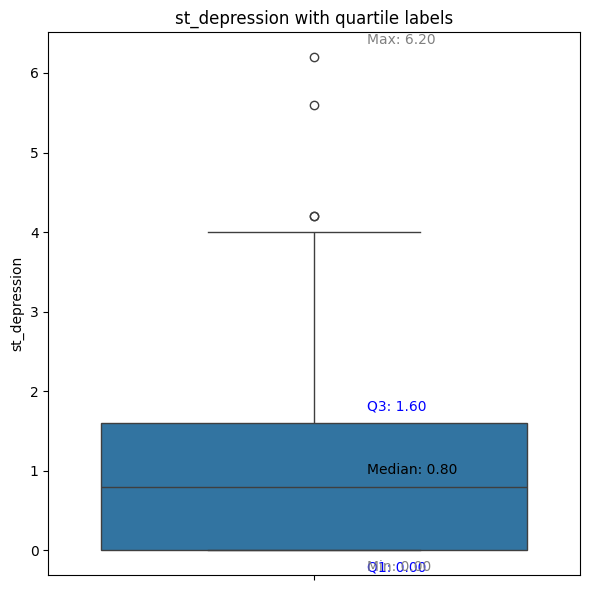

In [56]:
features = ['age', 'bp', 'cholesterol', 'max_hr', 'st_depression']

for col in features:
    s = df_heart_cleaned[col].dropna()

    q0 = s.min()
    q1 = s.quantile(0.25)
    q2 = s.quantile(0.50)
    q3 = s.quantile(0.75)
    q4 = s.max()

    plt.figure(figsize=(6, 6))
    ax = sns.boxplot(y=s)

    x_pos = 0
    dy = (q4 - q0) * 0.02  # 2% of range

    ax.text(x_pos + 0.1, q2 + dy, f'Median: {q2:.2f}', va='bottom', color='black')
    ax.text(x_pos + 0.1, q1 - dy, f'Q1: {q1:.2f}', va='top', color='blue')
    ax.text(x_pos + 0.1, q3 + dy, f'Q3: {q3:.2f}', va='bottom', color='blue')
    ax.text(x_pos + 0.1, q0 - dy, f'Min: {q0:.2f}', va='top', color='grey')
    ax.text(x_pos + 0.1, q4 + dy, f'Max: {q4:.2f}', va='bottom', color='grey')

    ax.set_ylabel(col)
    ax.set_title(f'{col} with quartile labels')
    plt.tight_layout()
    plt.show()


## Age Boxplot Findings: 
- Average of the patients is 55 years old 
- The middle 50% of the patients are between 48 - 61 years old
- We have a wide range of patients from early adults to senior citizens 
- Age values are not hevaily skewed (whiskers are about the same length) and will not need transformation 

## Blood Pressure
- The middle 50% of the patients have a Systolic BP of 120 - 140 (Ranging from Normal to Stage 2 Hypertension) 
- Minimum systolic BP is 94 and the maximum is 200
- There are some clear outliers on the upper whisker, meaning we have a right skewed distributions (take this into consideration when choosing a model)

## Cholesterol 
- Average Cholesterol level is 245, while the middle 50% of sitting between 213 and 280. 
- The middle 50% of the patients have elevated levels of cholesterol levels (boderline high to high levels) 
- the Minimum is 126; suggesting healthy cholesterol levels
- Several outliers present between cholesteroil levels at 390 and 564

## Maxt Heart Rate 
- Average Max heart rate is about 153.5. 
- He middle 50% percent of the patients have a max heart rate between 133 and 166 beats per minute 
- One outlier below the bottom whisker (left skewed) shows a max heart rate of 71 beats per min. (clinicallyinteresting)

## ST Depression 
- Average depression of 0.80 mm, while the middle 50% of patients have an ST depression between 0mm and 1.60mm
- Skewed right with outliers above the top whisker between 4.1mm to 6.20 mm

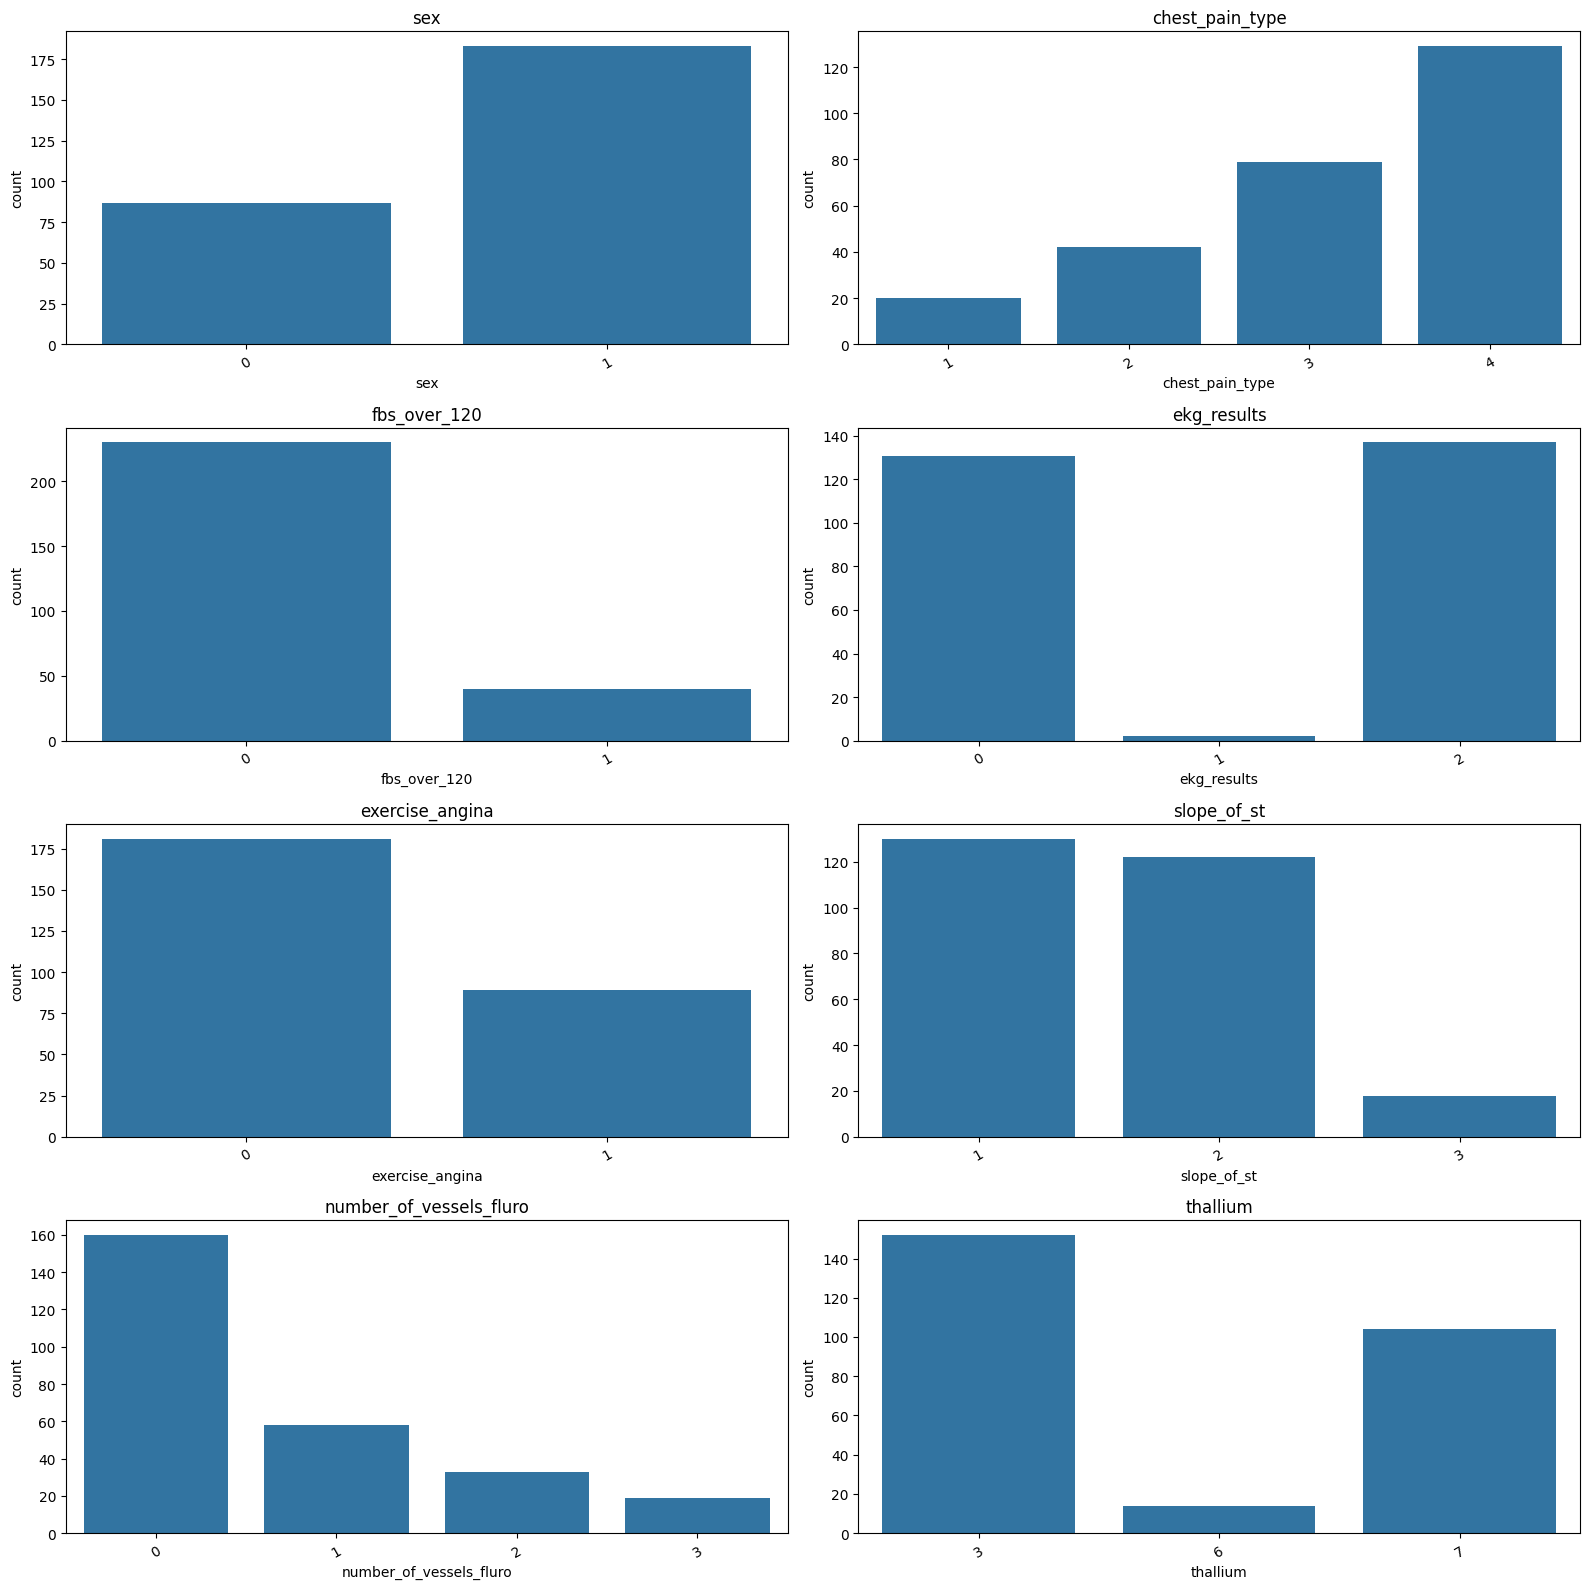

In [57]:
cat_cols = [
    'sex', 'chest_pain_type', 'fbs_over_120', 'ekg_results',
    'exercise_angina', 'slope_of_st', 'number_of_vessels_fluro','thallium'
]

plt.figure(figsize=(16, 16))

for i, col in enumerate(cat_cols, 1):
    ax = plt.subplot(4, 2, i)
    sns.countplot(x=col, data=df_heart_cleaned, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [58]:

pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

for col in cat_cols:
    print(f'\nColumn: {col} by percentage distribution')
    print(df_heart_cleaned[col].value_counts(normalize=True).mul(100).round(2))



Column: sex by percentage distribution
sex
1    67.78
0    32.22
Name: proportion, dtype: float64

Column: chest_pain_type by percentage distribution
chest_pain_type
4    47.78
3    29.26
2    15.56
1     7.41
Name: proportion, dtype: float64

Column: fbs_over_120 by percentage distribution
fbs_over_120
0    85.19
1    14.81
Name: proportion, dtype: float64

Column: ekg_results by percentage distribution
ekg_results
2    50.74
0    48.52
1     0.74
Name: proportion, dtype: float64

Column: exercise_angina by percentage distribution
exercise_angina
0    67.04
1    32.96
Name: proportion, dtype: float64

Column: slope_of_st by percentage distribution
slope_of_st
1    48.15
2    45.19
3     6.67
Name: proportion, dtype: float64

Column: number_of_vessels_fluro by percentage distribution
number_of_vessels_fluro
0    59.26
1    21.48
2    12.22
3     7.04
Name: proportion, dtype: float64

Column: thallium by percentage distribution
thallium
3    56.30
7    38.52
6     5.19
Name: proportion

## Data Features Explained

### Sex
- 1 = male  
- 0 = female  

### Chest Pain Type
- 4 = Asymptomatic  
- 3 = Non-anginal chest pain  
- 2 = Atypical angina  
- 1 = Typical angina  

### FBS over 120 (Fasting Blood Sugar > 120)
- 1 = Yes  
- 0 = No  

### EKG Results
- 2 = Probable left ventricular hypertrophy  
- 1 = ST-T wave abnormality  
- 0 = Normal  

### Exercise Angina
- 1 = Yes  
- 0 = No  

### Slope of ST
- 3 = Downsloping: strong indicator of coronary heart disease  
- 2 = Flat/horizontal: moderate indicator of coronary heart disease (inadequate flow to the heart muscle)  
- 1 = Upsloping: lowest risk of coronary heart disease (normal response to stress)  

### Number of Vessels Fluoro
- 0, 1, 2, or 3 vessels have narrowed  

### Thallium
- 3 = Normal blood flow  
- 6 = Fixed defect: reduced blood flow at rest and stress, usually indicating previous heart attack  
- 7 = Reversible defect: normal blood flow at rest and reduced flow during stress (ischemia, significant narrowing, high risk)  


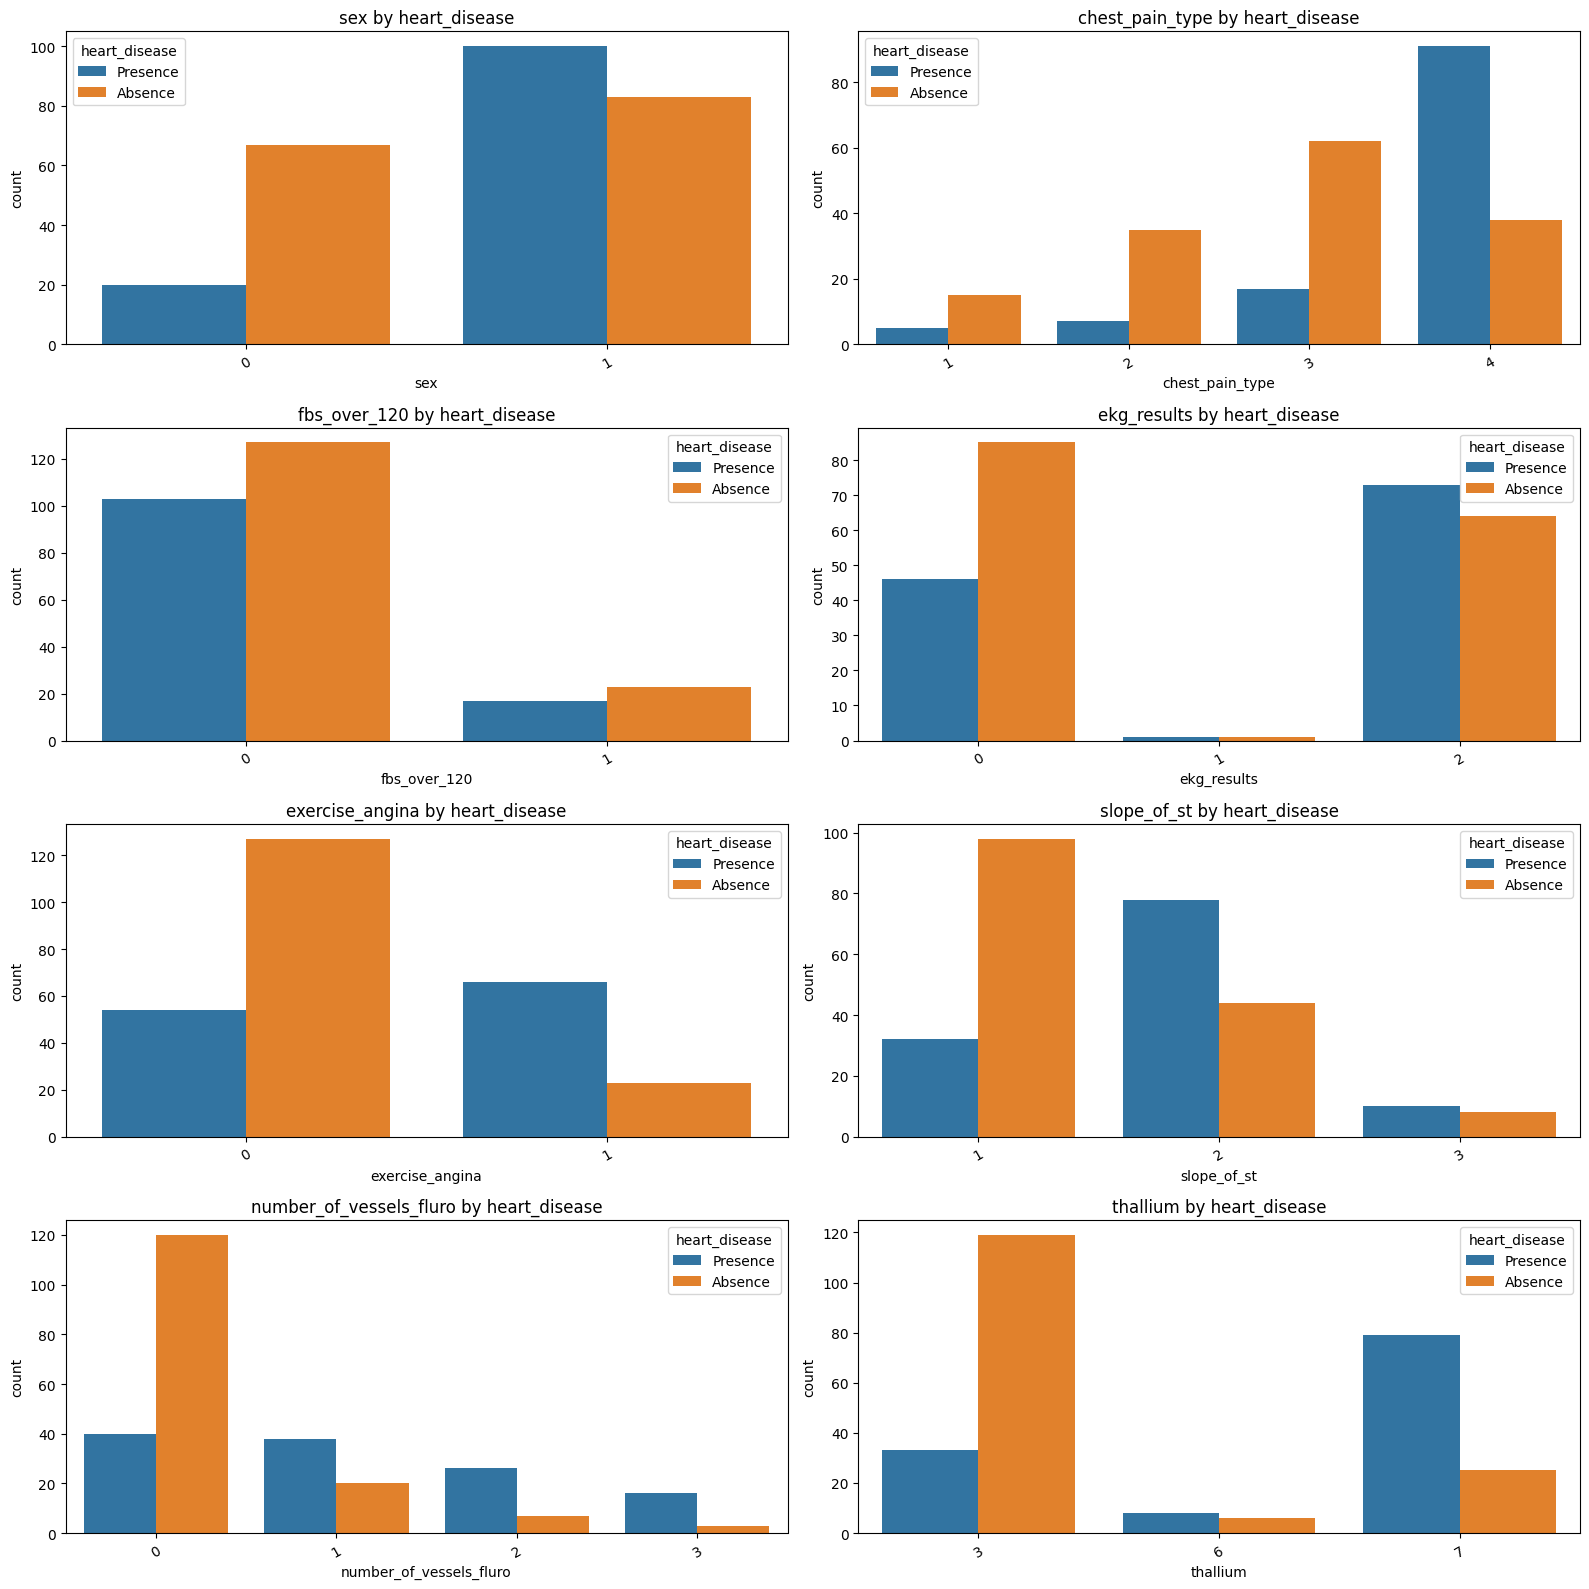

In [59]:
plt.figure(figsize=(16, 16))

for i, col in enumerate(cat_cols, 1):
    ax = plt.subplot(4, 2, i)
    sns.countplot(x=col, hue='heart_disease', data=df_heart_cleaned, ax=ax)
    ax.set_title(f'{col} by heart_disease')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## Insights for Categorical Features by Heart Disease 

1. sex by heart disease: The presence of heart disease is more common in males compared to females. Overall, females show heart disease to be less common but still show a relatively high number of cases. This suggests sex may have a moderate association with heart disease risk

2. Chest pain type by heart disease: Presence of heart disease is most common in patients that are asymptomatic. Presence of heart disease has the 2nd highest count in patients with non-anginal chest pain. Patients with absence of heart disease are also found for all types. Chest pain type appears to be strongly associated with heart disease status

3. fasting blood sugar over 120: absence of heart disease outweighs the presence of heart disease regardless of whether the fasting blood sugar levels being over 120 or not.This feature may have very limited predictive value. 

4. EKG results by heart disease: Most patients are classified between having normal EKG results and showing probable left ventricular hypertrophy. Absence of heart disease is commonn in patients with a normal EKG and the presence of heart disease is more common in patients with left ventricular hypertrophy. The difference is noticeable but not as strong as other variables.

5. Exercise Angina by Heart DIsease: Patients without exercise angina tend not to have heart disease, while those with exercise angina more often do, indicating a strong association

6. Slope of ST by Heart Disease: presence of heart disease is more common in patients with a flat/horizontal slope. Heart disease is 2nd most common in patients with downsloping. Patients with upsloping are less likely to have heart disease.

7. Number of blood vessels fluro: Presence of heart disease is much more common when at least one vessel is visible, and relatively rare when no vessels are visible.

8. Thallium by Heart Disease: heart disease is most common in patients that have normal blood flow at rest and reduced blood flow during stress. Heart Disease is less common in patients with reduced blood flow at rest and stress. Patients with normal blood flow are less likely to have heart disease. Thallium is a strong discriminator (or strong separating feature) between diseased and non‑diseased patients. 

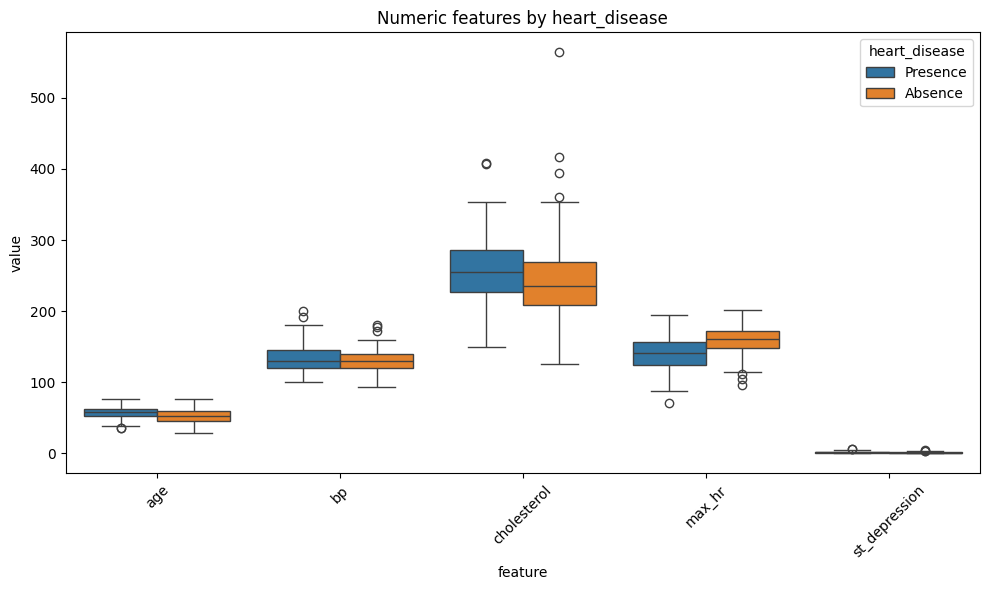

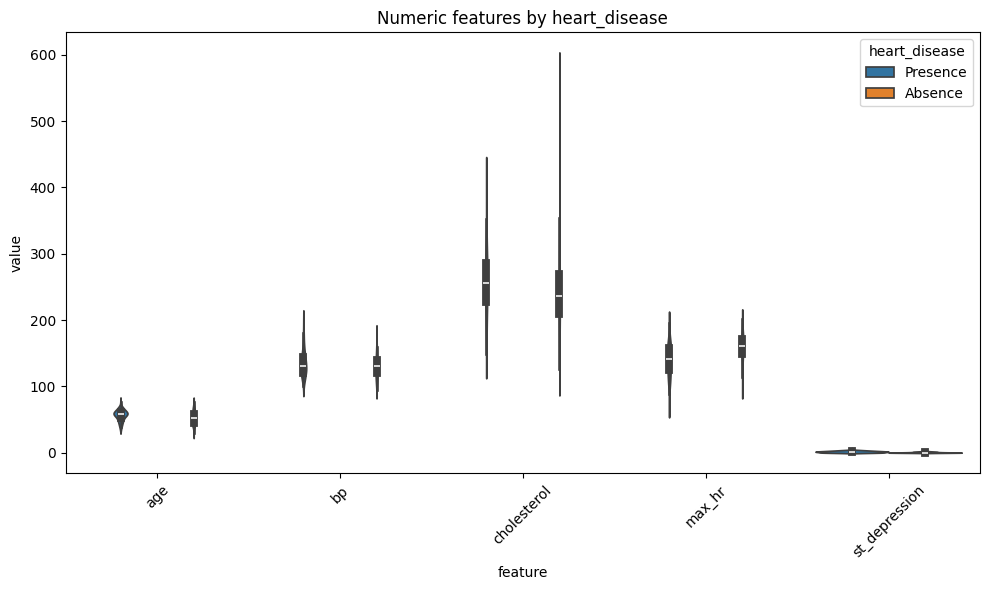

In [60]:
num_cols = ['age', 'bp', 'cholesterol', 'max_hr', 'st_depression']

df_long = df_heart_cleaned.melt(
    id_vars='heart_disease',
    value_vars=num_cols,
    var_name='feature',
    value_name='value'
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_long, x='feature', y='value', hue='heart_disease')
plt.title('Numeric features by heart_disease')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.violinplot(data=df_long, x='feature', y='value', hue='heart_disease', split=False)
plt.title('Numeric features by heart_disease')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


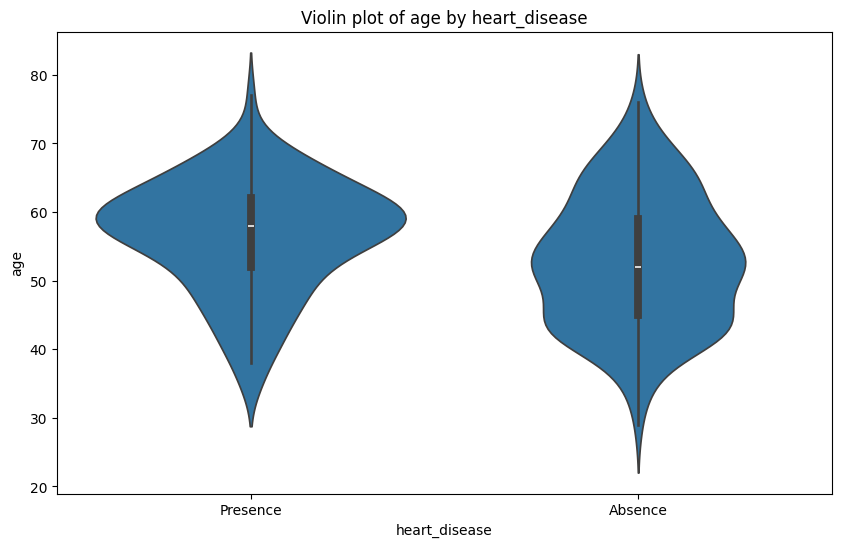

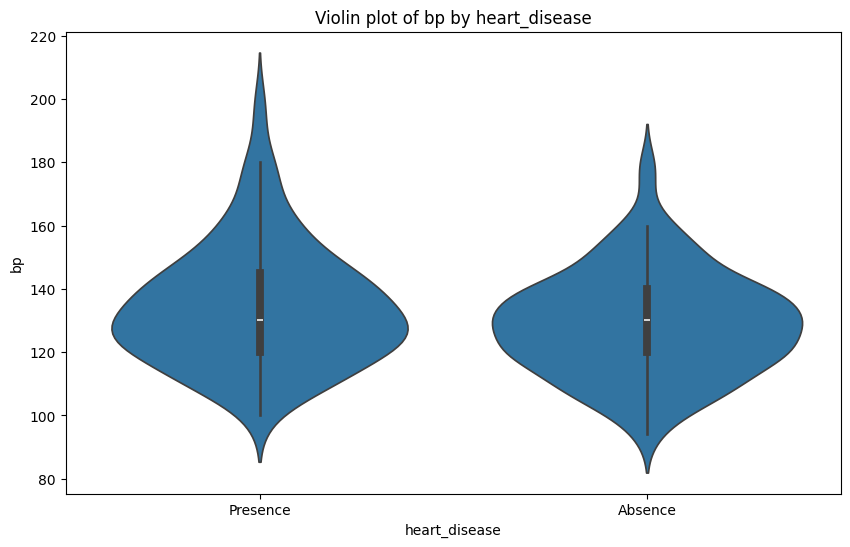

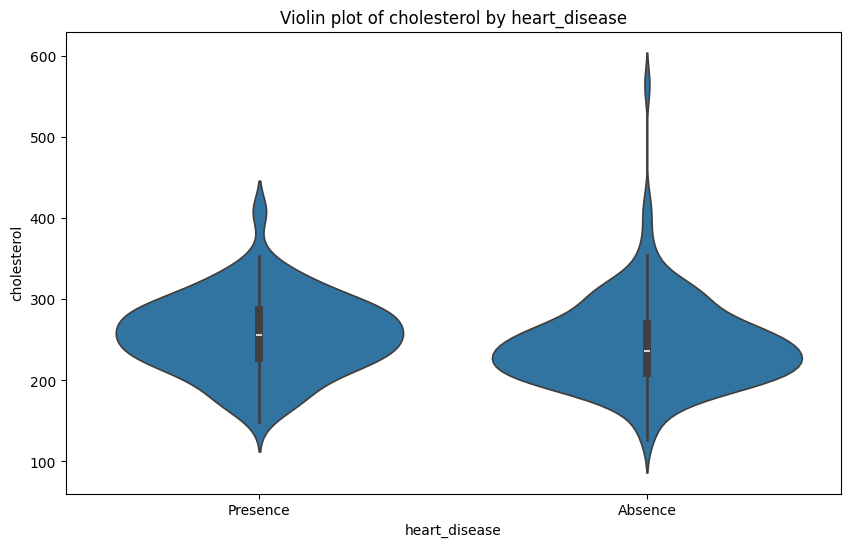

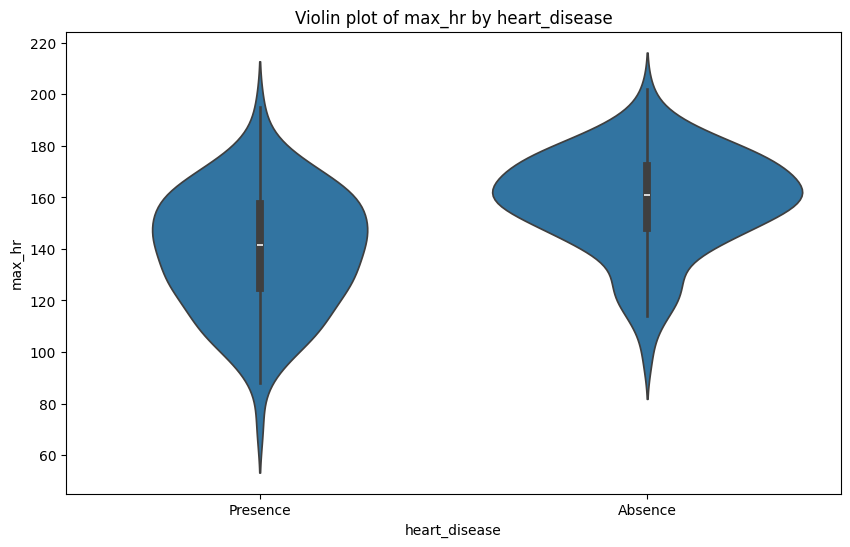

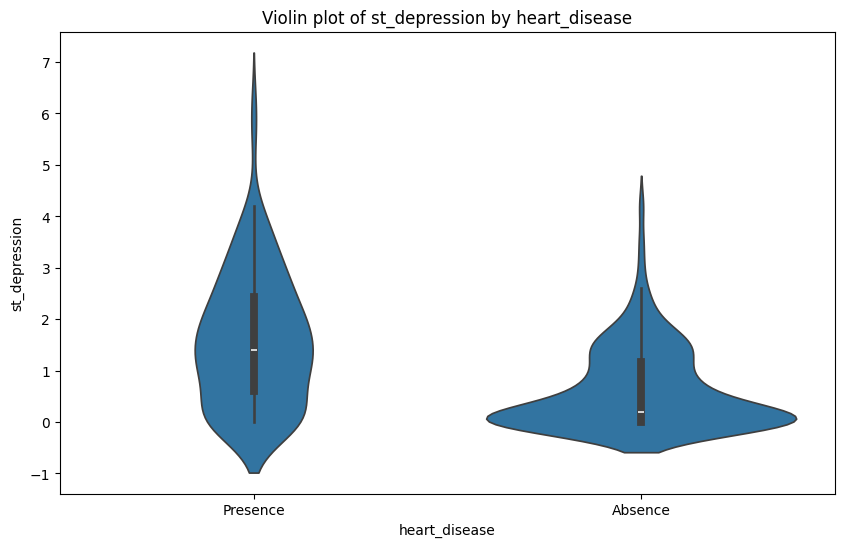

In [61]:

# Violin plots
for col in num_cols:
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df_heart_cleaned, x='heart_disease', y=col, inner='box')
    plt.title(f'Violin plot of {col} by heart_disease')
    plt.show()

## Insights for Continious Features by Heart Disease 

1. Age By Heart Disease: 
- Both groups span the adult age range, but distributions differ.
The Presence group is centered in the late 50s–early 60s with a median around 58 years, slightly higher than the Absence group (median ~50 years, clustered in the 40s–late 50s).
- This suggests older age is associated with a higher likelihood of heart disease in this cohort.

2. Blood Pressure by Heart Disease
- Blood pressure varies widely in both groups (roughly 90–200 mm Hg) with several outliers.
- Both Presence and Absence groups are concentrated around 110–140 mm Hg, and their medians are very similar (~130 mm Hg).
- This suggests resting blood pressure alone does not clearly distinguish between patients with and without heart disease in this sample.

3. Cholesterol by Heart Disease 
- Cholesterol shows a broad distribution in both groups; the Absence group has notable high outliers above 450 mg/dL
- The Presence group has a median around 250 mg/dL, with most values between 200–300 mg/dL, while the Absence group’s median is slightly lower (~225–230 mg/dL), mostly 185–250 mg/dL
- This pattern suggests higher cholesterol levels are associated with heart disease, though the overlap indicates it is not a perfect discriminator

4. Max HR by Heart Disease 
- The Presence group’s max heart rate ranges from <60 to ~210 bpm, with most observations between 100–170 bpm and a median around 140 bpm
- The Absence group ranges roughly 80–210 bpm, with most between 140–180 bpm and a higher median (~160 bpm)
- Overall, patients with heart disease tend to achieve lower maximum heart rates, consistent with reduced exercise capacity.

5. St Depression by Heart Disease 
- The Presence group shows a wider range of ST depression, from slightly above baseline to about 7 mm below baseline, with a median around 1.4 mm and most values between roughly −0.5 and 3 mm
- The Absence group ranges from slightly above baseline to about 5 mm below, but the median is 0 mm, with most values tightly clustered between −0.5 and 0.5 mm
- This indicates that greater ST depression is more common among patients with heart disease, aligning with ischemia-related ST changes.

In [62]:
## Describe by heart_disease

df_heart_cleaned.groupby('heart_disease').describe()

age                                                     \
               count       mean       std   min   25%   50%   75%   max   
heart_disease                                                             
Absence        150.0  52.706667  9.509830  29.0  45.0  52.0  59.0  76.0   
Presence       120.0  56.591667  8.116273  35.0  52.0  58.0  62.0  77.0   

                  bp                                                     \
               count        mean        std    min    25%    50%    75%   
heart_disease                                                             
Absence        150.0  128.866667  16.457660   94.0  120.0  130.0  140.0   
Presence       120.0  134.441667  19.095424  100.0  120.0  130.0  145.0   

                     cholesterol                                               \
                 max       count        mean        std    min     25%    50%   
heart_disease                                                                   
Absence        180.0       150.0  244.213333  54.019085  126.0  209.00  236.0   
Presence       200.0       120.0  256.466667  47.969166  149.0  227.25  255.5   

                             max_hr                                       \
                  75%    max  count        mean        std   min     25%   
heart_disease                                                              
Absence        268.75  564.0  150.0  158.333333  19.283357  96.0  148.25   
Presence       286.50  409.0  120.0  138.858333  23.130719  71.0  124.75   

                                    st_depression                           \
                 50%     75%    max         count      mean       std  min   
heart_disease                                                                
Absence        161.0  172.00  202.0         150.0  0.622667  0.800851  0.0   
Presence       141.5  157.25  195.0         120.0  1.584167  1.282067  0.0   

                                     
               25%  50%    75%  max  
heart_disease                        
Absence        0.0  0.2  1.175  4.2  
Presence       0.6  1.4  2.425  6.2

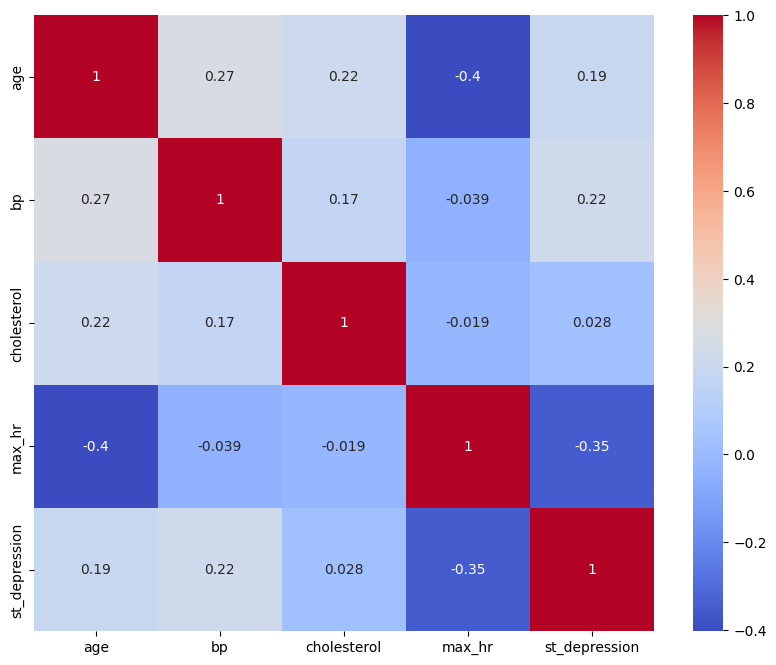

In [69]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_heart_cleaned[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()
## Features "move together" when their correlation is closest to -1 ot 1
## Negative values indicate an inverse relationship
## positive values indicate a direct relationship

## Heatmap Insights
- Max Heart rate and Age are the most correlated (negative) - As age increases, Max Heart Rate Decreases
- Max Heart Rate and ST Depsression are the 2nd most correlated (negative) - Max Heart rate is associated with a lower ST Depression

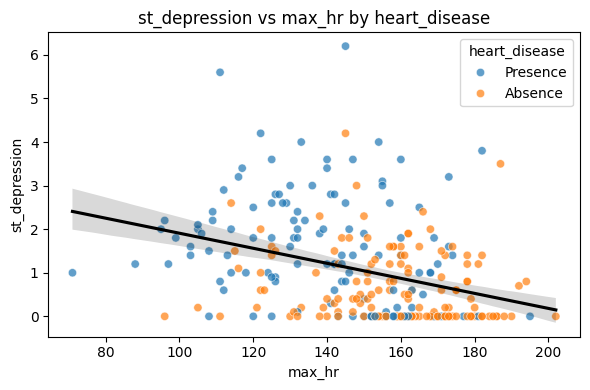

In [68]:
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=df_heart_cleaned,
    x='max_hr',
    y='st_depression',
    hue='heart_disease',
    alpha=0.7
)
sns.regplot(
    data=df_heart_cleaned,
    x='max_hr',
    y='st_depression',
    scatter=False,
    color='black'
)
plt.title('st_depression vs max_hr by heart_disease')
plt.tight_layout()

Text(0.5, 1.02, 'Numeric relationships by heart_disease')

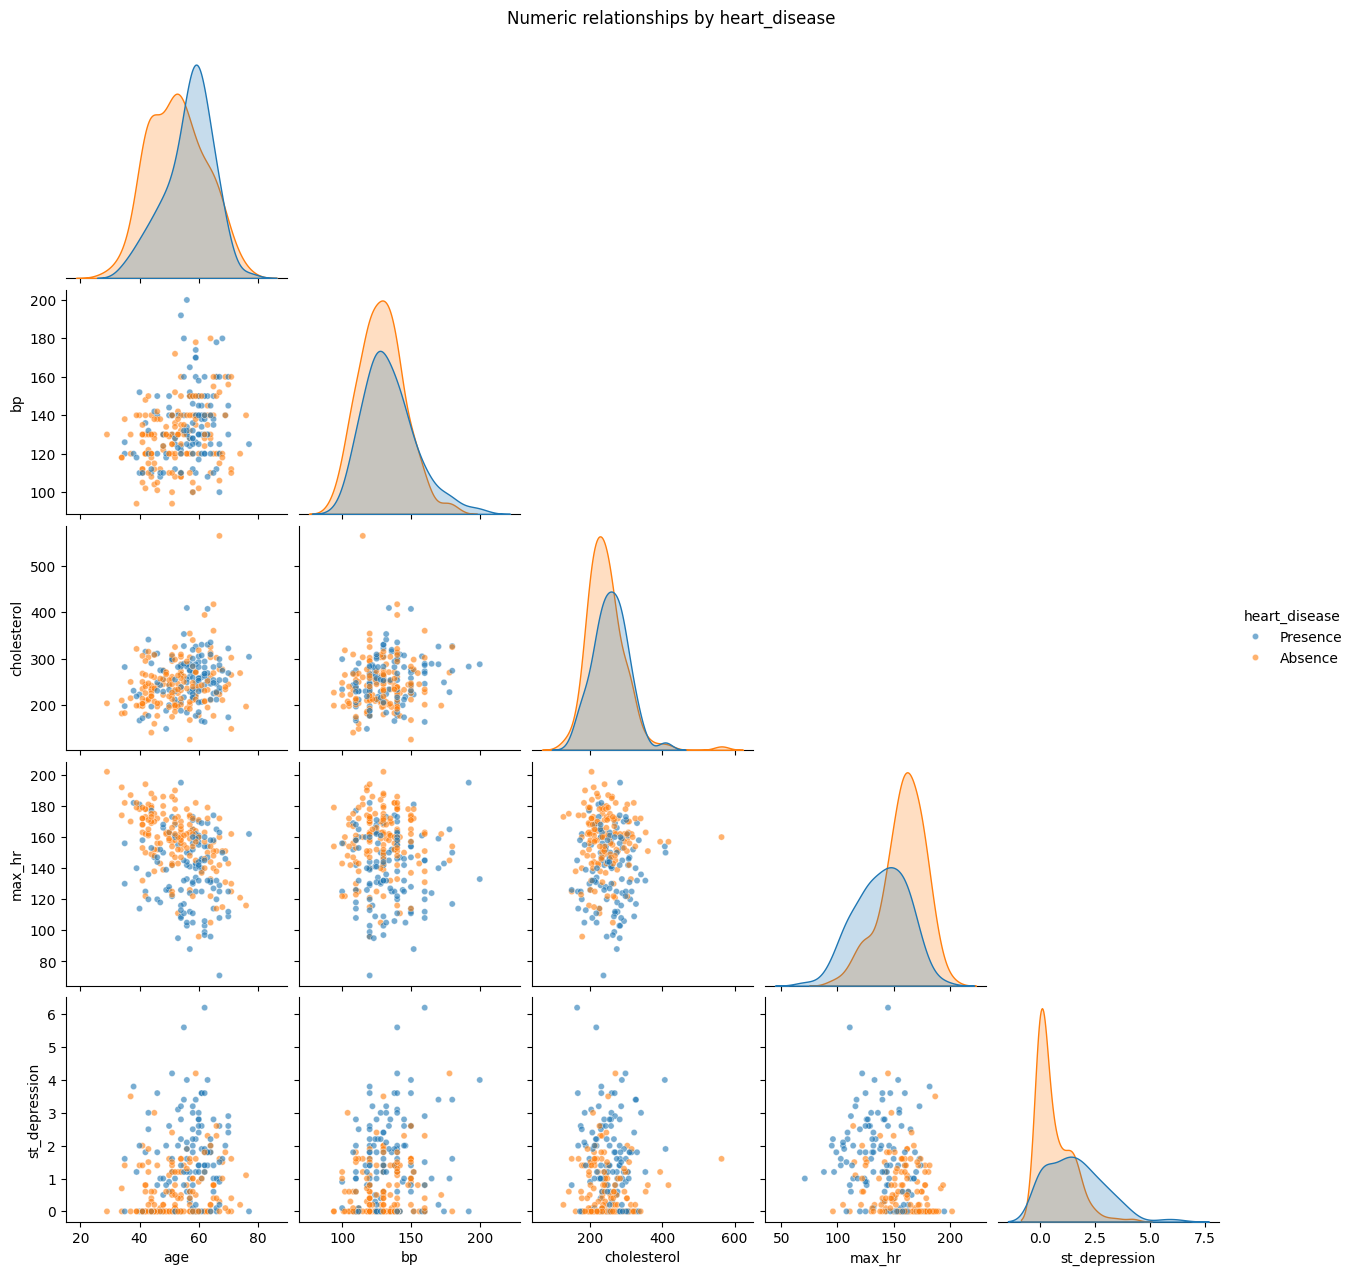

In [70]:
sns.pairplot(
    df_heart_cleaned[num_cols + ['heart_disease']],
    hue='heart_disease',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6, 's': 20}
)
plt.suptitle('Numeric relationships by heart_disease', y=1.02)

## Pairplot of Continuous Features by Heart Disease

- age vs max_hr: Slight downward trend (older → lower max_hr) 
- age vs st_depression: ST depression appears across most ages; diseased patients show more higher‑st_depression points but no sharp age cutoff
- bp vs max_hr: Very weak negative trend (higher bp, slightly lower max_hr), with strong overlap between classes
- bp vs st_depression: ST depression values spread across the bp range; diseased patients more often appear at higher st_depression but not at a unique bp band
- cholesterol vs max_hr: Very diffuse; max_hr differences by class do not strongly depend on cholesterol in this view.
- cholesterol vs st_depression: Diseased patients with higher st_depression appear across the cholesterol range; no tight joint structure
- max_hr vs st_depression: Loose negative trend; diseased points more frequent where st_depression is higher and max_hr is moderate, but overlap remains large.

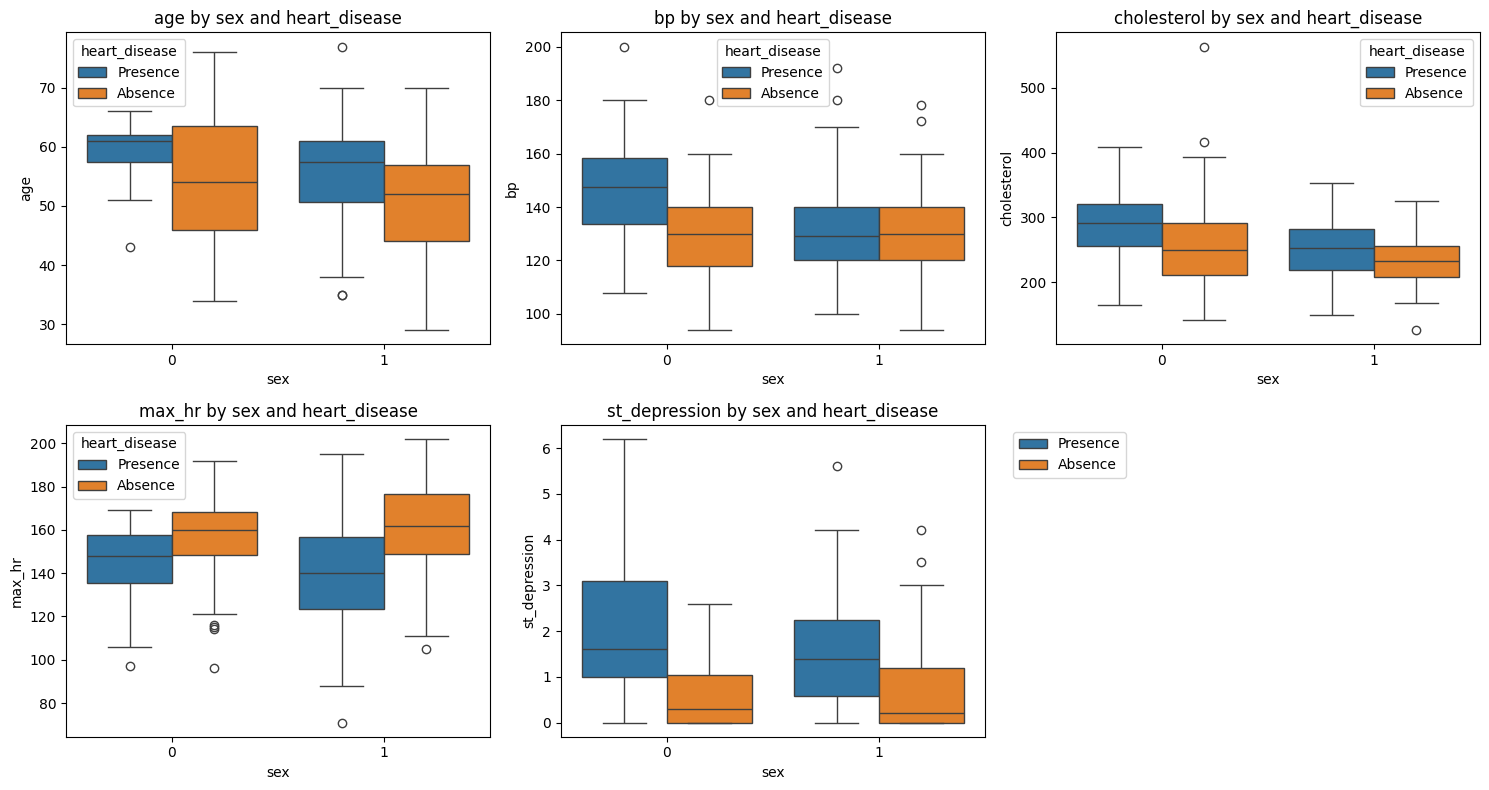

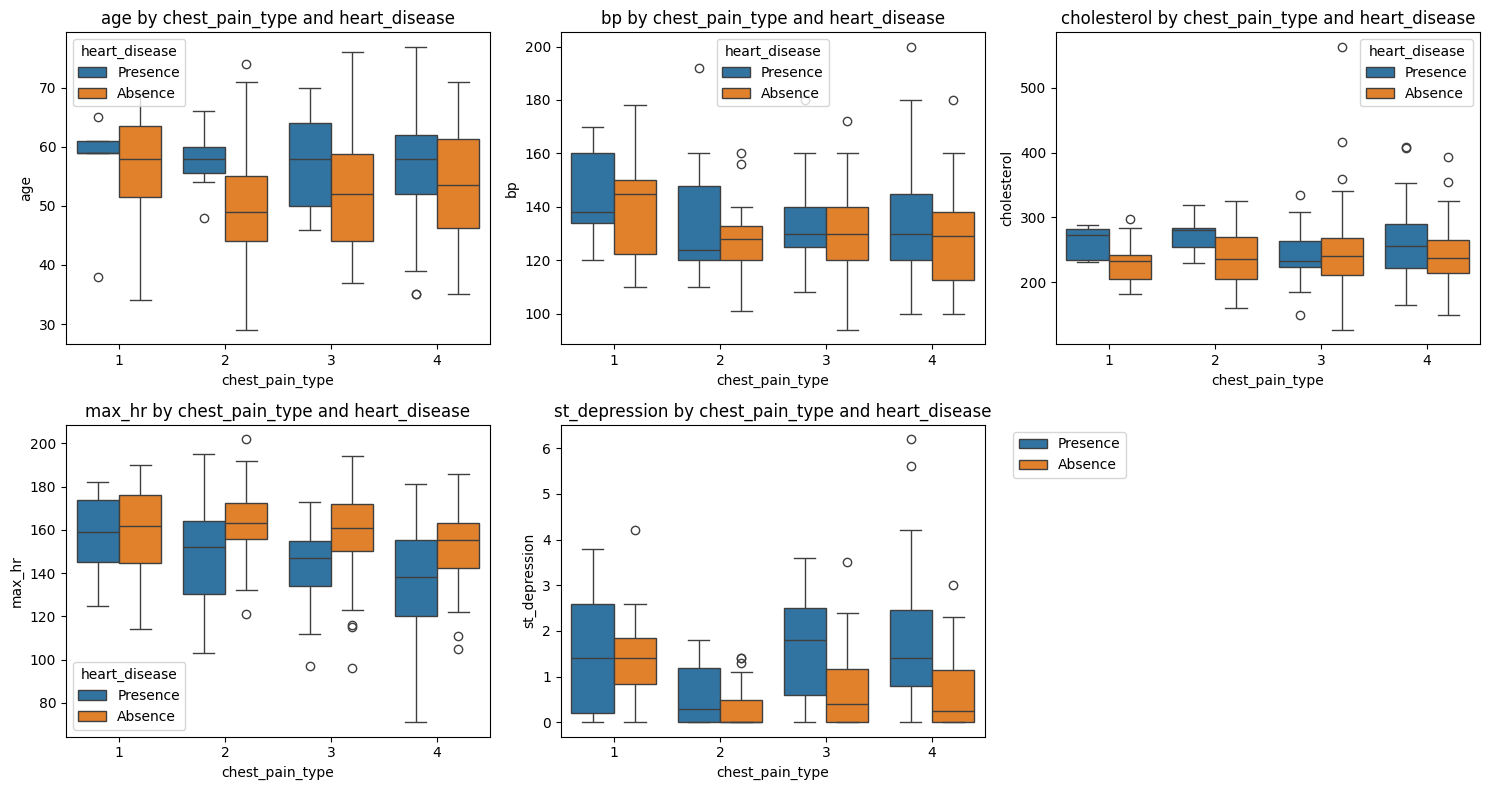

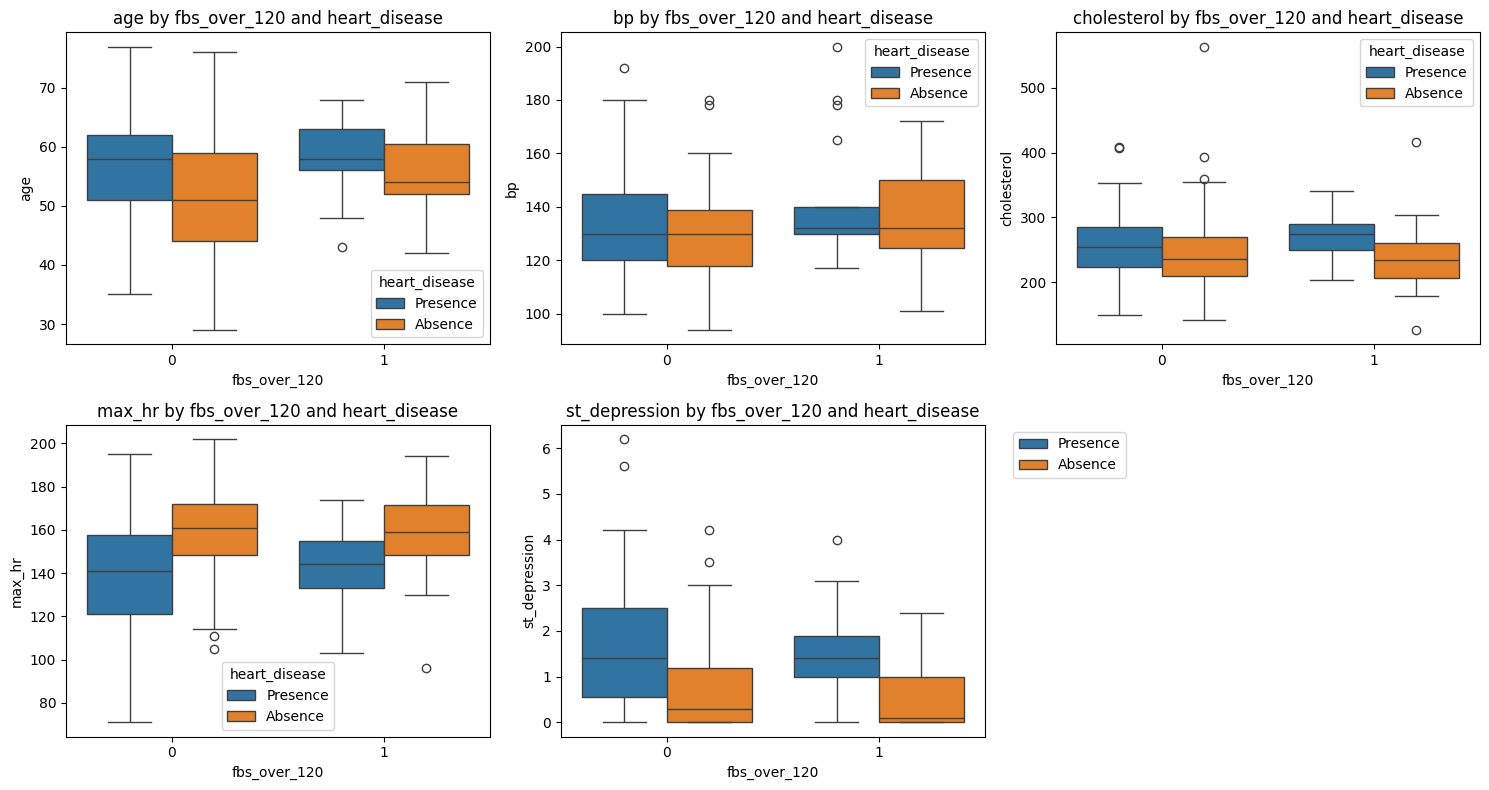

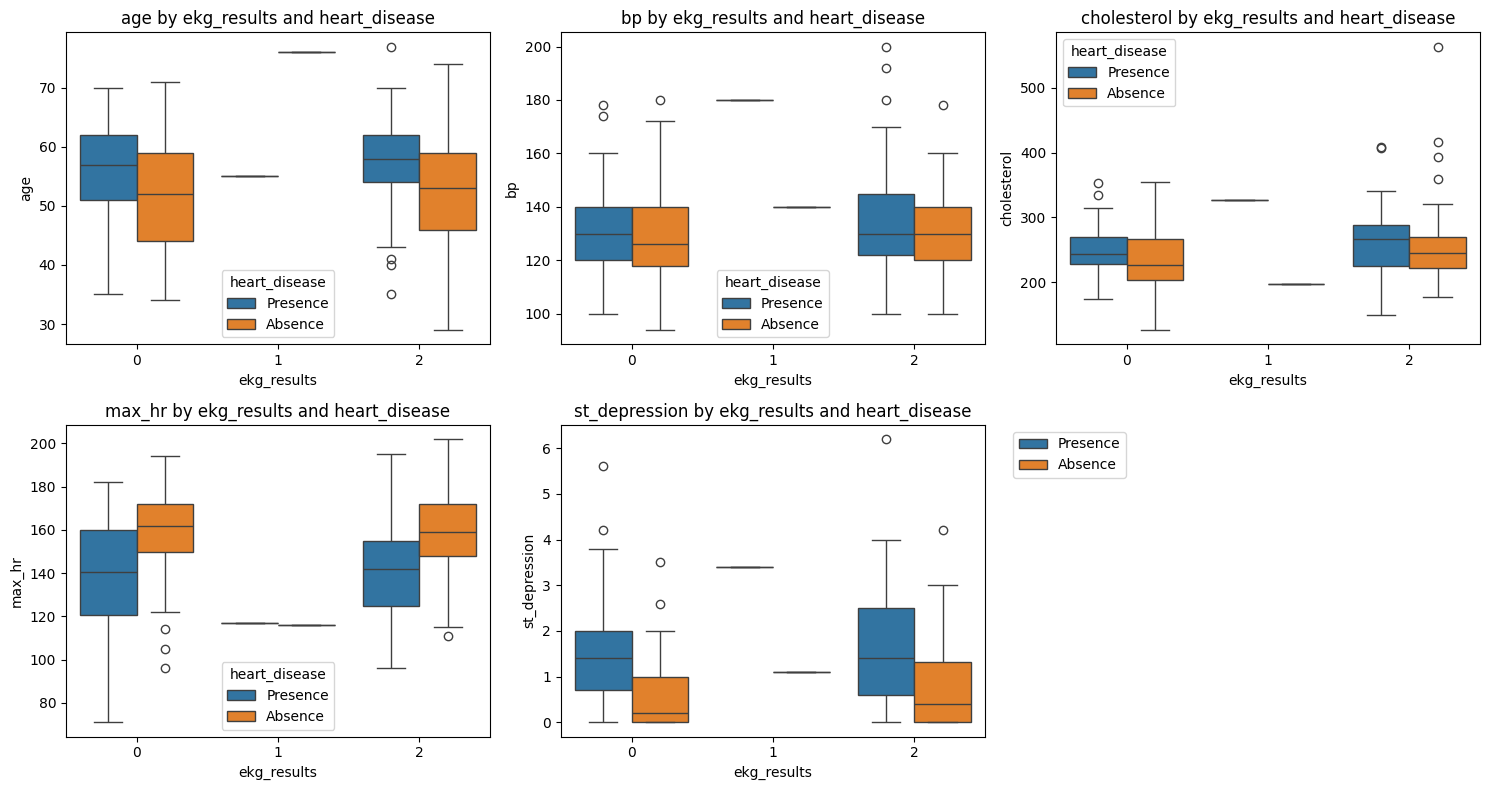

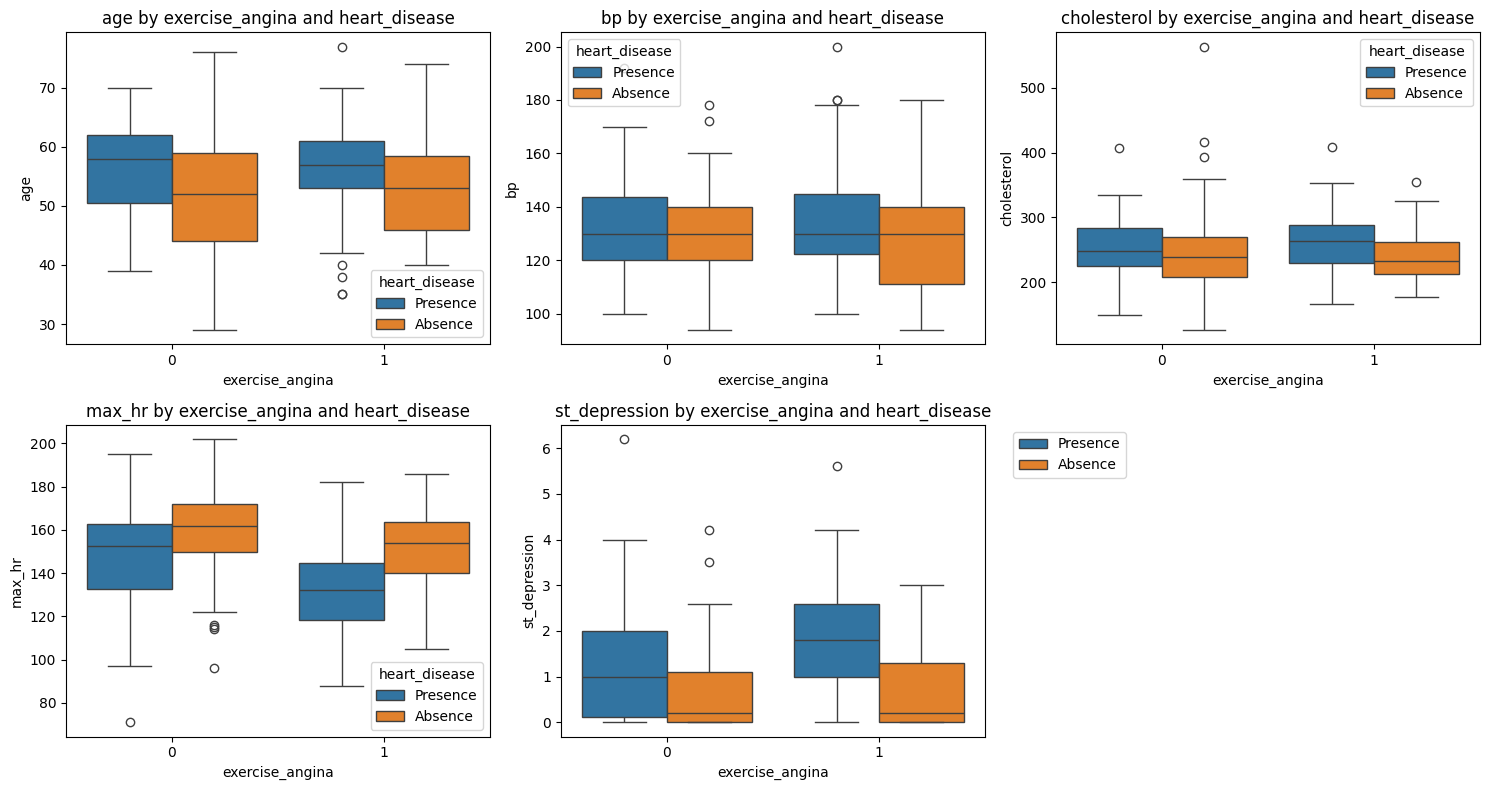

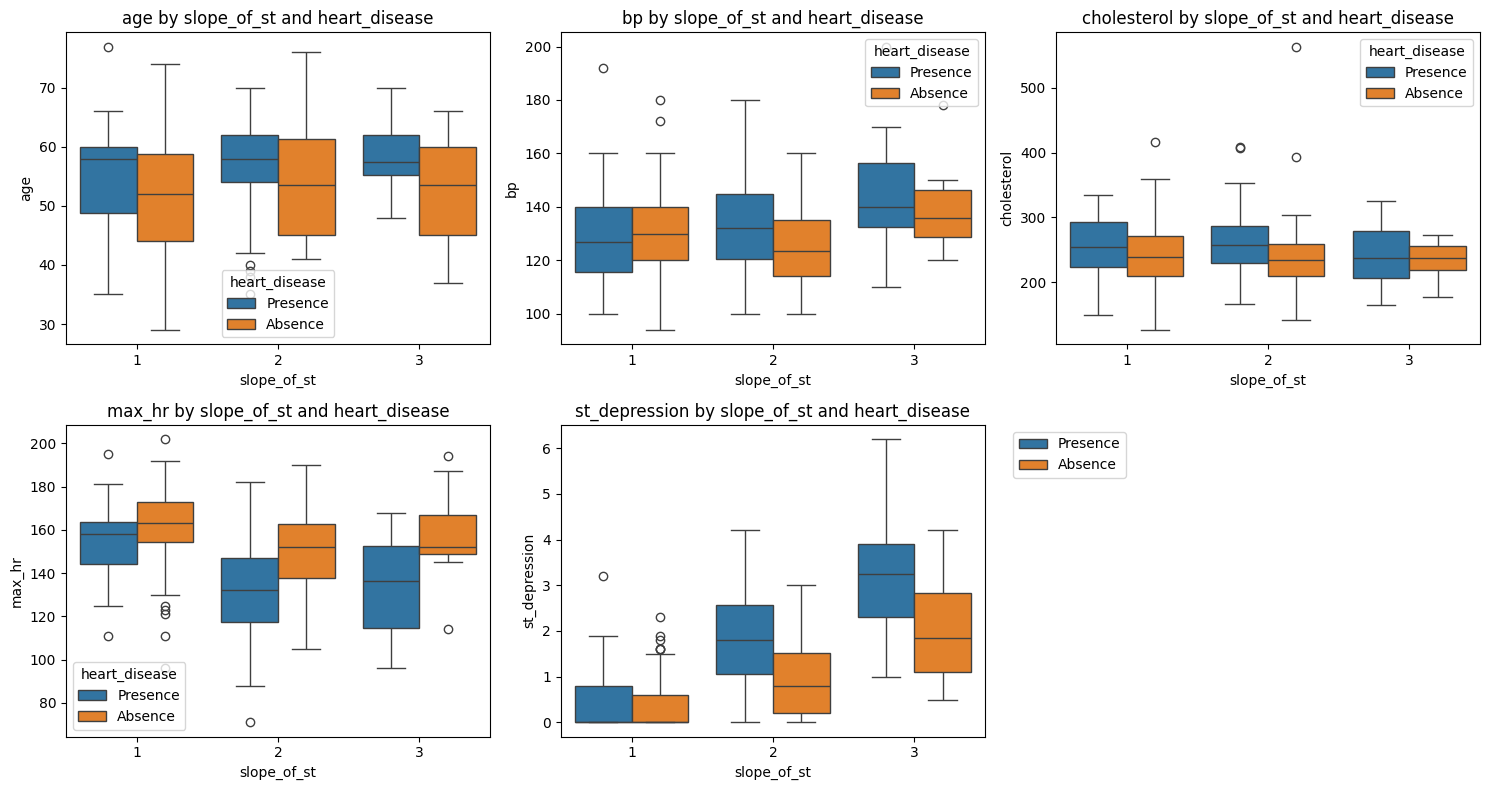

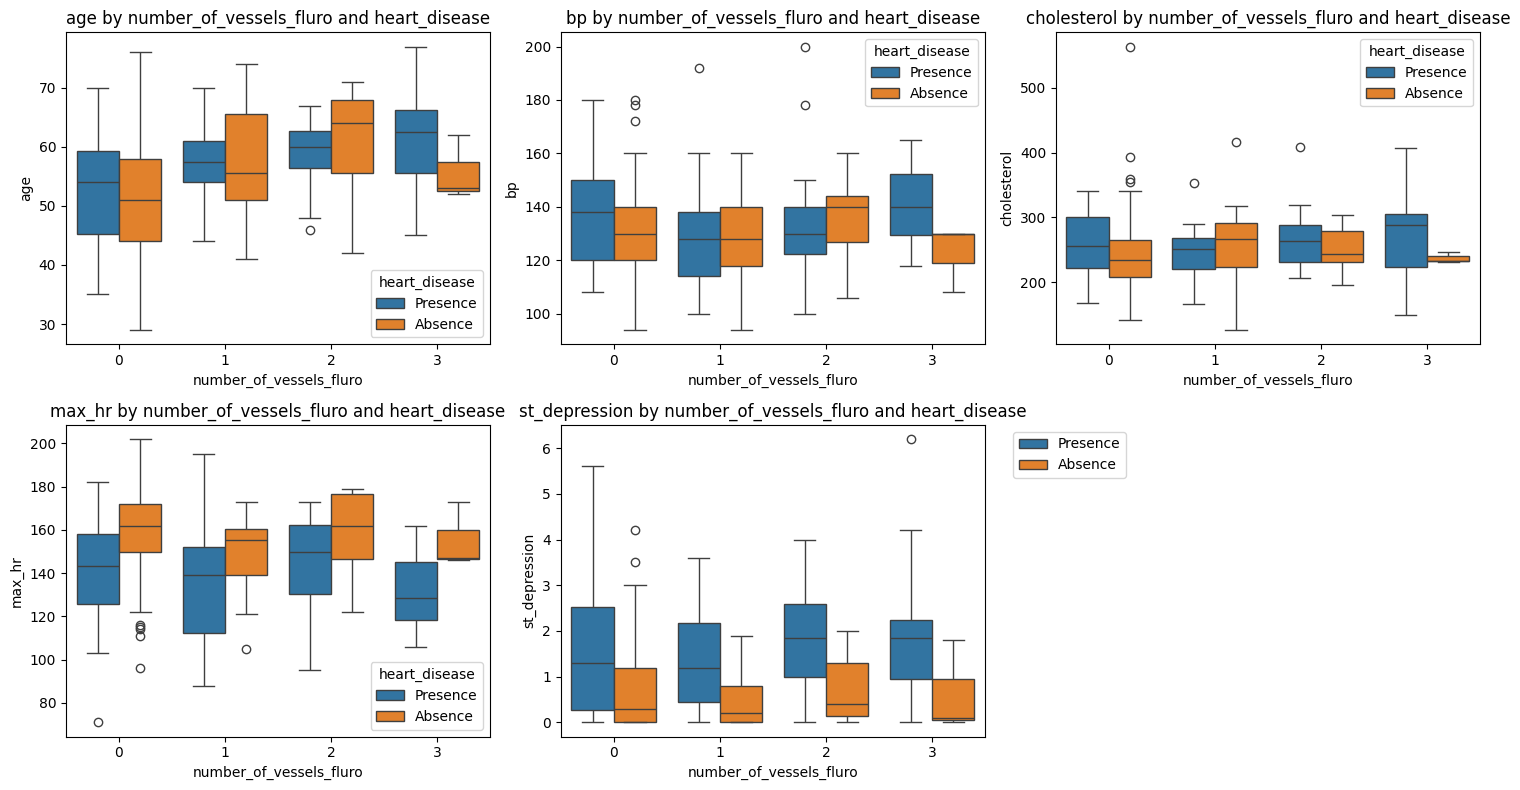

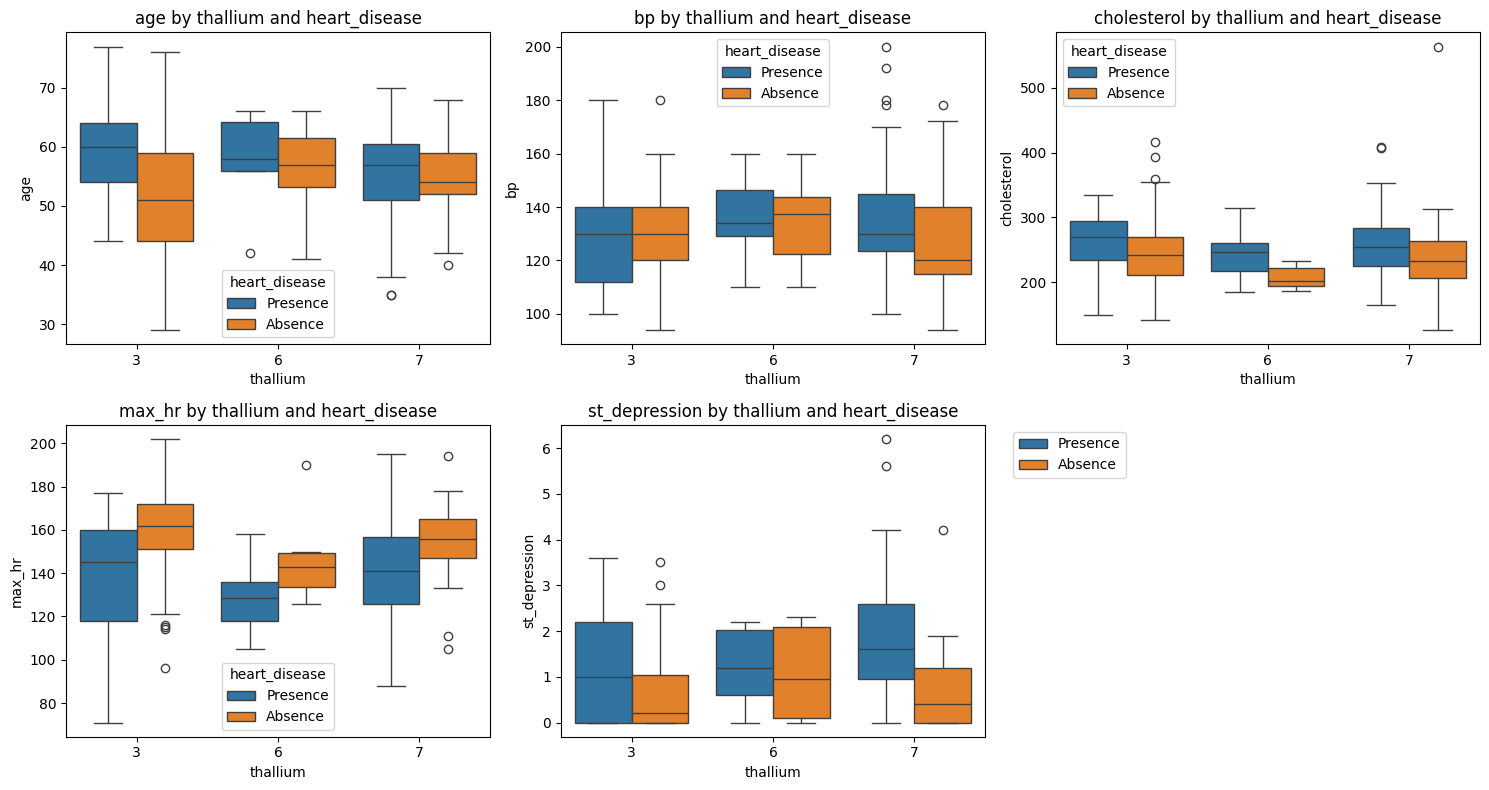

In [ ]:
cat_cols = [
    'sex', 'chest_pain_type', 'fbs_over_120', 'ekg_results',
    'exercise_angina', 'slope_of_st', 'number_of_vessels_fluro','thallium'
]
num_cols = ['age', 'bp', 'cholesterol', 'max_hr', 'st_depression']

for cat in cat_cols:
    plt.figure(figsize=(15, 8))
    for i, col in enumerate(num_cols, 1):
        plt.subplot(2, 3, i)
        sns.boxplot(
            data=df_heart_cleaned,
            x=cat,
            y=col,Ib 
            hue='heart_disease'
        )
        plt.title(f'{col} by {cat} and heart_disease')
    plt.tight_layout()
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

## Insignts for Bivariate comparison by Heart Disease 

- Max heart rate and ST depression seem to be the strongest indicators of heart disease being present. 
- Every other feature showed minimal to no noteable differences in distribution between the Presence and Absence of Heart Disease 